# Group Relative Policy Optimization (GRPO) & Critic-Free RL
1. First-Principles & Base Questioning
To understand why GRPO became the backbone of modern reasoning models (like DeepSeek-R1), we must first analyze why standard RL algorithms—specifically PPO (Proximal Policy Optimization)—hit a memory wall when scaling long reasoning sequences.

The PPO Memory WallStandard PPO requires maintaining four separate neural network models in GPU memory during training:Actor Network ($\pi_\theta$): The policy model being trained to generate responses.Reference Network ($\pi_{\text{ref}}$): A frozen copy of the base model used to compute KL divergence penalties (to keep the policy from drifting too far).Reward Network ($R_\psi$): The scoring model (ORM/PRM) that evaluates generation quality.Critic / Value Network ($V_\phi$): A model trained to predict expected future rewards $V(s_t)$ at every state $s_t$ to estimate the Advantage:$$A_t = R_t - V_\phi(s_t)$$                               ┌────────────────────────────────┐
                               │   PPO Memory Footprint (VRAM)  │
                               └────────────────────────────────┘
                                                │
         ┌──────────────────┬───────────────────┼───────────────────┐
         ▼                  ▼                   ▼                   ▼
  [ Actor (π_θ) ]    [ Reference (π_ref) ]  [ Reward (R_ψ) ]    [ Critic (V_ϕ) ]
  (Trainable 70B)      (Frozen 70B)           (Scoring Head)      (Trainable 70B)

The Fundamental Question: Can We Eliminate the Critic Entirely?If the Critic's sole job is to estimate baseline expected value $V(s_t)$ to calculate Advantage ($A = \text{Reward} - \text{Baseline}$), how can we get a reliable baseline without training a Value Model?The GRPO Solution:For a single prompt $q$, instead of sampling $1$ completion, we sample a group of $G$ outputs $\{o_1, o_2, \dots, o_G\}$ from the current policy $\pi_{\theta_{\text{old}}}$.We score all $G$ outputs using a reward function to get a vector of scalar rewards $\mathbf{r} = [r_1, r_2, \dots, r_G]$.The relative statistical baseline of the group serves as the Advantage:$$A_i = \frac{r_i - \text{mean}(\mathbf{r})}{\text{std}(\mathbf{r})}$$

Mathematical Formulation1. Group Advantage CalculationFor a prompt $q$ and a sampled group of $G$ outputs $\{o_1, o_2, \dots, o_G\}$ with rewards $\{r_1, r_2, \dots, r_G\}$:$$\bar{r} = \frac{1}{G} \sum_{i=1}^{G} r_i, \quad \sigma_r = \sqrt{\frac{1}{G} \sum_{i=1}^{G} (r_i - \bar{r})^2 + \epsilon}$$The advantage $A_i$ for output $o_i$ is constant across all tokens in that completion:$$A_i = \frac{r_i - \bar{r}}{\sigma_r}$$If $r_i > \bar{r}$ ($A_i > 0$): Output $o_i$ performed better than the group average. The policy gradient will increase the log-probabilities of all tokens in $o_i$.If $r_i < \bar{r}$ ($A_i < 0$): Output $o_i$ performed worse than average. The policy gradient will decrease the log-probabilities of tokens in $o_i$.

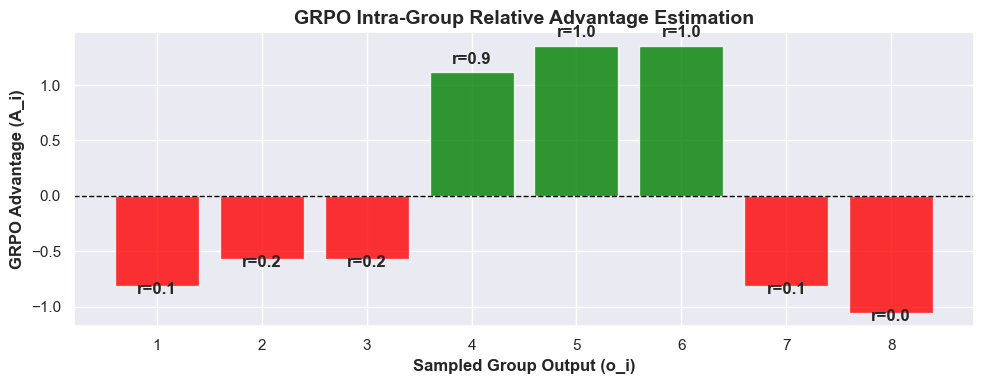

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

torch.manual_seed(42)

def compute_grpo_advantages(rewards: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Computes group-relative advantages.
    rewards: [group_size]
    returns: [group_size]
    """
    mean_r = torch.mean(rewards)
    std_r = torch.std(rewards, unbiased=False)
    advantages = (rewards - mean_r) / (std_r + eps)
    return advantages


def compute_grpo_loss(
    log_probs_current: torch.Tensor,
    log_probs_old: torch.Tensor,
    log_probs_ref: torch.Tensor,
    advantages: torch.Tensor,
    clip_eps: float = 0.2,
    beta_kl: float = 0.04
):
    """
    Computes token-level GRPO loss over a group of completions.
    
    log_probs_current: [group_size, seq_len]
    log_probs_old: [group_size, seq_len]
    log_probs_ref: [group_size, seq_len]
    advantages: [group_size]
    """
    group_size, seq_len = log_probs_current.shape
    
    # Expand advantages across sequence dimension
    adv_expanded = advantages.unsqueeze(-1) # [group_size, 1]
    
    # 1. Compute probability ratio: r_t = exp(log_p_current - log_p_old)
    ratios = torch.exp(log_probs_current - log_probs_old) # [group_size, seq_len]
    
    # 2. Compute surrogate losses
    surr1 = ratios * adv_expanded
    surr2 = torch.clamp(ratios, 1.0 - clip_eps, 1.0 + clip_eps) * adv_expanded
    policy_loss = -torch.min(surr1, surr2) # Objective to maximize -> minimize negative
    
    # 3. Compute unbiased token-level KL divergence penalty
    # KL = (ref / current) - log(ref / current) - 1
    prob_ratio_kl = torch.exp(log_probs_ref - log_probs_current)
    kl_div = prob_ratio_kl - (log_probs_ref - log_probs_current) - 1.0
    
    # 4. Combine policy loss and KL penalty
    total_token_loss = policy_loss + beta_kl * kl_div
    
    # Average across tokens and group members
    total_loss = total_token_loss.mean()
    return total_loss, policy_loss.mean().item(), kl_div.mean().item()


# --- SIMULATION & VISUALIZATION ---
group_size = 8
seq_len = 10

# Simulated raw rewards for 8 candidate outputs
rewards = torch.tensor([0.1, 0.2, 0.2, 0.9, 1.0, 1.0, 0.1, 0.0])
advantages = compute_grpo_advantages(rewards)

# Visualizing Advantage Distribution
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['green' if a > 0 else 'red' for a in advantages.numpy()]
bars = ax.bar(range(1, group_size + 1), advantages.numpy(), color=colors, alpha=0.8)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Sampled Group Output (o_i)', fontsize=12, fontweight='bold')
ax.set_ylabel('GRPO Advantage (A_i)', fontsize=12, fontweight='bold')
ax.set_title('GRPO Intra-Group Relative Advantage Estimation', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, group_size + 1))

# Add value labels
for bar, r in zip(bars, rewards.numpy()):
    yval = bar.get_height()
    offset = 0.05 if yval >= 0 else -0.1
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + offset, f'r={r:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

def compute_grpo_advantages(rewards: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    mean_r = torch.mean(rewards)
    std_r = torch.std(rewards, unbiased=False)
    if std_r == 0:
        return torch.zeros_like(rewards)
    return (rewards - mean_r) / (std_r + eps)


def compute_grpo_loss(
    log_probs_current: torch.Tensor,
    log_probs_old: torch.Tensor,
    log_probs_ref: torch.Tensor,
    advantages: torch.Tensor,
    clip_eps: float = 0.2,
    beta_kl: float = 0.01
):
    group_size, seq_len = log_probs_current.shape
    adv_expanded = advantages.unsqueeze(-1) # [group_size, 1]
    
    # Probability Ratio: r_t = exp(log_p_current - log_p_old)
    ratios = torch.exp(log_probs_current - log_probs_old)
    
    # Clipped Surrogate Objective
    surr1 = ratios * adv_expanded
    surr2 = torch.clamp(ratios, 1.0 - clip_eps, 1.0 + clip_eps) * adv_expanded
    policy_loss = -torch.min(surr1, surr2).mean()
    
    # Token-level KL Divergence
    prob_ratio_kl = torch.exp(log_probs_ref - log_probs_current)
    kl_div = (prob_ratio_kl - (log_probs_ref - log_probs_current) - 1.0).mean()
    
    total_loss = policy_loss + beta_kl * kl_div
    return total_loss


class MiniPolicyNetwork(nn.Module):
    def __init__(self, vocab_size=50, d_model=32):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.gru = nn.GRU(d_model, d_model, batch_first=True)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        e = self.embed(x)
        out, _ = self.gru(e)
        return self.head(out)


class GRPOTrainer:
    def __init__(self, policy, ref_policy, group_size=8, lr=1e-3):
        self.policy = policy
        self.ref_policy = ref_policy
        self.group_size = group_size
        self.optimizer = torch.optim.Adam(self.policy.parameters(), lr=lr)

    def rollout_group(self, prompt_ids: torch.Tensor, gen_len: int = 6):
        """
        Samples G completions and captures log_probs_old during generation.
        """
        self.policy.eval()
        prompt_len = prompt_ids.shape[1]
        input_ids = prompt_ids.repeat(self.group_size, 1)
        sampled_log_probs = []

        with torch.no_grad():
            for _ in range(gen_len):
                logits = self.policy(input_ids)[:, -1, :]
                probs = F.softmax(logits, dim=-1)
                log_probs = F.log_softmax(logits, dim=-1)
                
                next_tokens = torch.multinomial(probs, num_samples=1)
                token_log_p = log_probs.gather(dim=-1, index=next_tokens)
                
                sampled_log_probs.append(token_log_p)
                input_ids = torch.cat([input_ids, next_tokens], dim=1)

        completions = input_ids[:, prompt_len:]
        old_log_probs = torch.cat(sampled_log_probs, dim=1) # [G, gen_len]
        return input_ids, completions, old_log_probs

    def compute_rule_reward(self, completions: torch.Tensor) -> torch.Tensor:
        # Verifiable reward: Sum of generated token IDs is even (+1.0), else (0.0)
        token_sums = completions.sum(dim=-1)
        return (token_sums % 2 == 0).float()

    def train_step(self, prompt_ids: torch.Tensor, gen_len: int = 6):
        # 1. Rollout completions and record pi_old log-probs
        full_seqs, completions, old_log_probs = self.rollout_group(prompt_ids, gen_len)
        prompt_len = prompt_ids.shape[1]

        # 2. Compute Rewards and Group Advantages
        rewards = self.compute_rule_reward(completions)
        advantages = compute_grpo_advantages(rewards)

        # 3. Compute active gradients for pi_theta (Current Policy Pass)
        self.policy.train()
        logits_curr = self.policy(full_seqs)[:, prompt_len-1:-1, :]
        log_probs_curr_all = F.log_softmax(logits_curr, dim=-1)
        
        targets = completions.unsqueeze(-1)
        curr_log_probs = log_probs_curr_all.gather(dim=-1, index=targets).squeeze(-1)

        # 4. Compute Reference Model Pass
        with torch.no_grad():
            logits_ref = self.ref_policy(full_seqs)[:, prompt_len-1:-1, :]
            log_probs_ref_all = F.log_softmax(logits_ref, dim=-1)
            ref_log_probs = log_probs_ref_all.gather(dim=-1, index=targets).squeeze(-1)

        # 5. Calculate Loss & Optimize
        loss = compute_grpo_loss(
            log_probs_current=curr_log_probs,
            log_probs_old=old_log_probs,
            log_probs_ref=ref_log_probs,
            advantages=advantages,
            beta_kl=0.01
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return rewards.mean().item(), loss.item()


# --- VERIFICATION EXECUTION ---
if __name__ == "__main__":
    vocab_size = 50
    policy = MiniPolicyNetwork(vocab_size=vocab_size)
    ref_policy = MiniPolicyNetwork(vocab_size=vocab_size)
    ref_policy.load_state_dict(policy.state_dict())

    trainer = GRPOTrainer(policy, ref_policy, group_size=8, lr=1e-3)
    prompt = torch.tensor([[1, 2, 3]])

    print("=== Fixed GRPO Loop Execution ===")
    for epoch in range(1, 11):
        mean_reward, loss_val = trainer.train_step(prompt, gen_len=6)
        print(f"Epoch {epoch:02d} | Avg Group Reward: {mean_reward:.2f} | GRPO Loss: {loss_val:.6f}")


=== Fixed GRPO Loop Execution ===
Epoch 01 | Avg Group Reward: 0.25 | GRPO Loss: -0.000000
Epoch 02 | Avg Group Reward: 0.38 | GRPO Loss: 0.000000
Epoch 03 | Avg Group Reward: 0.62 | GRPO Loss: 0.000001
Epoch 04 | Avg Group Reward: 0.62 | GRPO Loss: 0.000001
Epoch 05 | Avg Group Reward: 0.62 | GRPO Loss: 0.000003
Epoch 06 | Avg Group Reward: 0.75 | GRPO Loss: 0.000003
Epoch 07 | Avg Group Reward: 0.62 | GRPO Loss: 0.000002
Epoch 08 | Avg Group Reward: 0.75 | GRPO Loss: 0.000003
Epoch 09 | Avg Group Reward: 0.12 | GRPO Loss: 0.000005
Epoch 10 | Avg Group Reward: 0.38 | GRPO Loss: 0.000004
